### 1. Data Importing and Cleaning

In [130]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import MaxNLocator

In [83]:
healthcare_facilities_df = pd.read_csv("C:/Users/tk_ko/Desktop/SGH/1. Hospital Admissions, Public Sector Outpatient Attendances And Day Surgery Counts.csv")

#### Hospital Admissions, Public Sector Outpatient Attendances and Day Surgery Counts

In [84]:
# Display the first 10 rows
healthcare_facilities_df.head(10)

,Healthcare Facilities,Admission Counts,Year,Month
0,Community Hospitals Admissions (Non-Public),na,1989,Sep
1,Psychiatric Hospitals Admissions (Non-Public),na,1993,Mar
2,Community Hospitals Admissions (Total),1609,2019,Jan
3,Polyclinics,435294,2016,Dec
4,Acute Hospitals Admissions (Public),na,1987,Jun
5,Acute Hospitals Admissions (Public),44184,2023,Aug
6,Polyclinics,478843,2017,Jun
7,Psychiatric Hospitals Admissions (Public),793,2010,Sep
8,Acute Hospitals Admissions (Public),na,1996,Oct
9,Specialist Outpatient Clinics,186011,1995,Nov


In [85]:
# Describe the info of each column
healthcare_facilities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6216 entries, 0 to 6215
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Healthcare Facilities  6216 non-null   object
 1   Admission Counts       6216 non-null   object
 2   Year                   6216 non-null   int64 
 3   Month                  6216 non-null   object
dtypes: int64(1), object(3)
memory usage: 194.4+ KB


In [86]:
# Admission Counts is a categorical variable. There could be odd one-off values besides numerical counts
# str converts each value to its string form before comparing, and allowed sorted to work
healthcare_unique_vals = healthcare_facilities_df['Admission Counts'].unique()
print(sorted(healthcare_unique_vals, key=str))

['0', '10008', '10012', '1002', '10024', '100280', '100401', '10046', '10062', '100627', '10063', '1007', '100725', '10073', '100750', '1008', '101', '101082', '101231', '10124', '101337', '101374', '1014', '101409', '10145', '101451', '101485', '101491', '101573', '1017', '10174', '10175', '1018', '101843', '102088', '102278', '102309', '1024', '10244', '1025', '102533', '10258', '102599', '102818', '103014', '10316', '103163', '103310', '10334', '1034', '103465', '103573', '103587', '103591', '103603', '10373', '10374', '103784', '1038', '10393', '103966', '104000', '1041', '10414', '104259', '104301', '104342', '1045', '104515', '104669', '10478', '104791', '104800', '1050', '105174', '105373', '105529', '10581', '105987', '106', '10623', '106251', '106255', '10636', '10641', '106468', '106469', '106567', '1066', '10666', '1072', '107209', '10734', '10744', '10751', '10767', '107704', '107737', '107898', '107991', '107999', '1080', '108001', '10807', '10814', '108181', '10840', '108

In [87]:
# Find rows where Admission Counts is 'na', removing leading and trailing spaces and checking whether the cleaned value is exactly 'na'
healthcare_na_mask = healthcare_facilities_df['Admission Counts'].astype(str).str.strip().eq('na')
healthcare_na_rows = healthcare_facilities_df[healthcare_na_mask]

# Confirm that na_rows only contain 'na'
healthcare_na_rows['Admission Counts'].value_counts(dropna=False)

Admission Counts
na    2268
Name: count, dtype: int64

In [88]:
# Keep only non-na rows
healthcare_facilities_df = healthcare_facilities_df[~healthcare_na_mask]

# Confirm there are no more 'na' rows
healthcare_facilities_df['Admission Counts'].astype(str).str.strip().eq('na').sum()

np.int64(0)

In [89]:
# Convert Admission Counts from object to numeric
healthcare_facilities_df['Admission Counts'] = pd.to_numeric(healthcare_facilities_df['Admission Counts'])

In [90]:
# Sanity check on Admission Counts column to check the distribution of values using describe()
# Admission Counts has a large variance, with a high maximum value of 627,174 that is still a possible value
healthcare_facilities_df['Admission Counts'].describe().T

count      3948.000000
mean      92139.220111
std      132747.562852
min           0.000000
25%         792.750000
50%       37385.500000
75%       97916.500000
max      627174.000000
Name: Admission Counts, dtype: float64

# Pending Commentary for above

In [91]:
# Check for nulls
healthcare_facilities_df.isnull().sum()

Healthcare Facilities    0
Admission Counts         0
Year                     0
Month                    0
dtype: int64

In [92]:
# Check for duplicate rows
healthcare_duplicates = healthcare_facilities_df.duplicated()
healthcare_facilities_df[healthcare_duplicates]

,Healthcare Facilities,Admission Counts,Year,Month


In [93]:
# Exploring the range of values in the remaining columns to check unexpected values
print(healthcare_facilities_df['Healthcare Facilities'].value_counts(), '\n')
print(healthcare_facilities_df['Year'].value_counts().sort_index(), '\n')
print(healthcare_facilities_df['Month'].value_counts().sort_index(), '\n')

Healthcare Facilities
Polyclinics                                      444
Specialist Outpatient Clinics                    444
Dental Clinics                                   444
Accident & Emergency Departments                 444
Day Surgeries                                    228
Community Hospitals Admissions (Total)           216
Acute Hospitals Admissions (Public)              216
Psychiatric Hospitals Admissions (Public)        216
Community Hospitals Admissions (Non-Public)      216
Acute Hospitals Admissions (Total)               216
Acute Hospitals Admissions (Non-Public)          216
Psychiatric Hospitals Admissions (Total)         216
Community Hospitals Admissions (Public)          216
Psychiatric Hospitals Admissions (Non-Public)    216
Name: count, dtype: int64 

Year
1987     48
1988     48
1989     48
1990     48
1991     48
1992     48
1993     48
1994     48
1995     48
1996     48
1997     48
1998     48
1999     48
2000     48
2001     48
2002     48
2003     48

# Pending Commentary for above

#### Exploratory Data Analysis 1

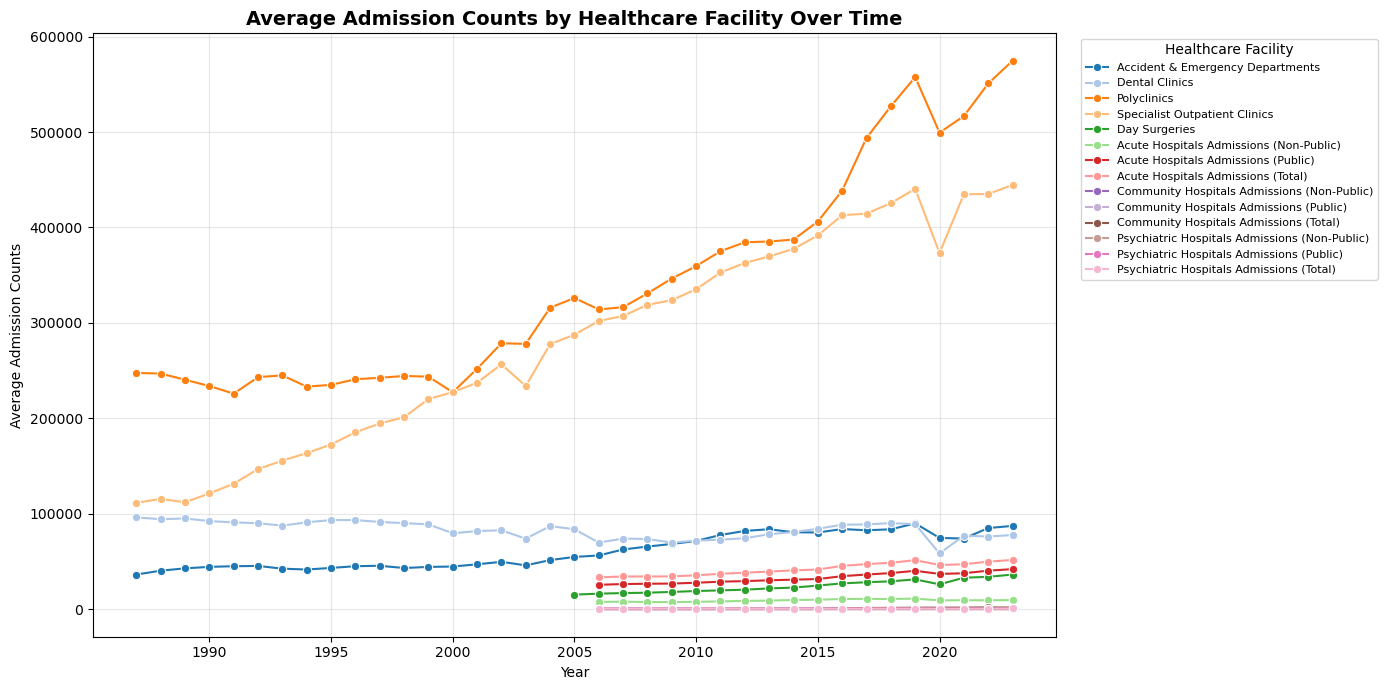

In [112]:
# 1. Admission counts over time per healthcare facility
# Reason: Compare long-term trends, identify crossing between facilities and what it can mean for periods of growth and decline
# Viz: x-axis = Year, y-axis = Admission Counts, Legend = Healthcare facility type

yearly_admissions = (
    healthcare_facilities_df
    .dropna(subset=['Admission Counts'])
    .groupby(['Year', 'Healthcare Facilities'], as_index=False)['Admission Counts']
    .mean()
)

# Line chart of Admission Counts Over Time by Healthcare Facility
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=yearly_admissions,
    x='Year',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette=sns.color_palette('tab20', n_colors=yearly_admissions['Healthcare Facilities'].nunique()),
    marker='o'
)
plt.title('Average Admission Counts by Healthcare Facility Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Admission Counts')
plt.legend(title='Healthcare Facility', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Polyclinics and Specialist Outpatient Clinics have the highest admissions across all years, significantly above all other faciltiies. Both facilities showed an upward trend over the years. Accident & Emergency Departments and Dental Clinics are the next most admitted.

# Pending Commentary for above

In [95]:
# 2. Summarize each facility type with average, min, max, median, standard deviation
# Reason: Especially standard deviation where admission counts can vary across years and months
# Viz: Boxplot with IQR

# Printing summary statistics per facility type
summary_stats = (
    healthcare_facilities_df
    .groupby('Healthcare Facilities')['Admission Counts']
    .agg(
        Mean='mean',
        Min='min',
        Max='max',
        Median='median',
        Std_Dev='std'
    )
    .round(2)
    .sort_values('Std_Dev', ascending=False)
)

summary_stats

,Mean,Min,Max,Median,Std_Dev
Healthcare Facilities,,,,,
Specialist Outpatient Clinics,280450.86,94190,513912,284383.5,112051.87
Polyclinics,339633.75,195841,627174,314124.0,111952.47
Dental Clinics,83319.93,8157,123131,86565.5,19076.53
Accident & Emergency Departments,60719.07,33988,98385,55237.5,17912.44
Day Surgeries,24156.86,10393,40448,22702.0,6933.00
Acute Hospitals Admissions (Total),42113.77,29498,54993,41215.0,6581.34
Acute Hospitals Admissions (Public),32887.70,23028,44504,31508.0,5530.81
Acute Hospitals Admissions (Non-Public),9226.06,6470,11968,9237.0,1299.36
Community Hospitals Admissions (Total),1088.07,373,2786,814.5,523.31


Standard deviation increases with mean and median. This is fairly expected especially for Specialist Outpatient Clinics and Polyclinics with high admission volumes.

Community Hospitals Admissions (Public) has a larger standard deviation (447.99) than mean (410.62), which supports the high variability suggested in the previous chart. However, there is a strong right-skew pattern for Community Hospitals (both Total and Public) where mean is above the median, indicating that Community Hospitals show a greater upward trend rather than random variance.

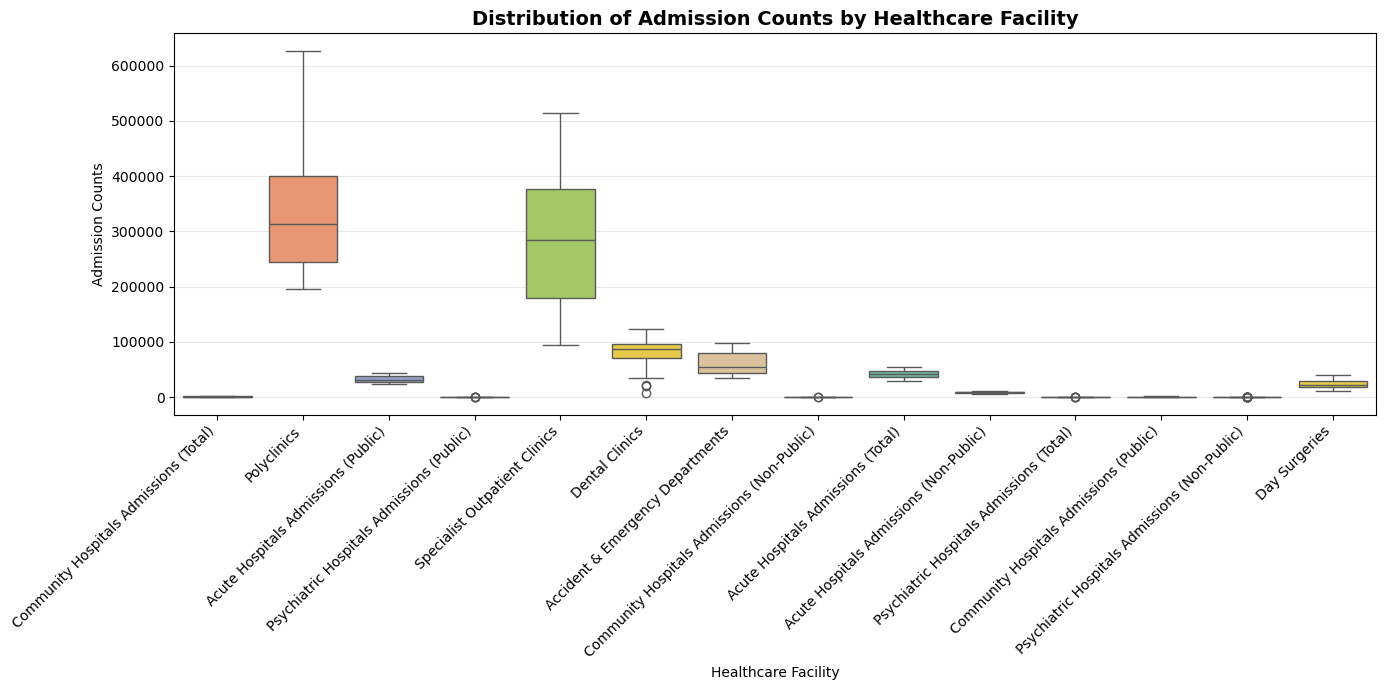

In [17]:
# Displaying the summary stats into a Boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=healthcare_facilities_df,
    x='Healthcare Facilities',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette='Set2',
    legend=False
)

plt.title('Distribution of Admission Counts by Healthcare Facility', fontsize=14, fontweight='bold')
plt.xlabel('Healthcare Facility')
plt.ylabel('Admission Counts')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

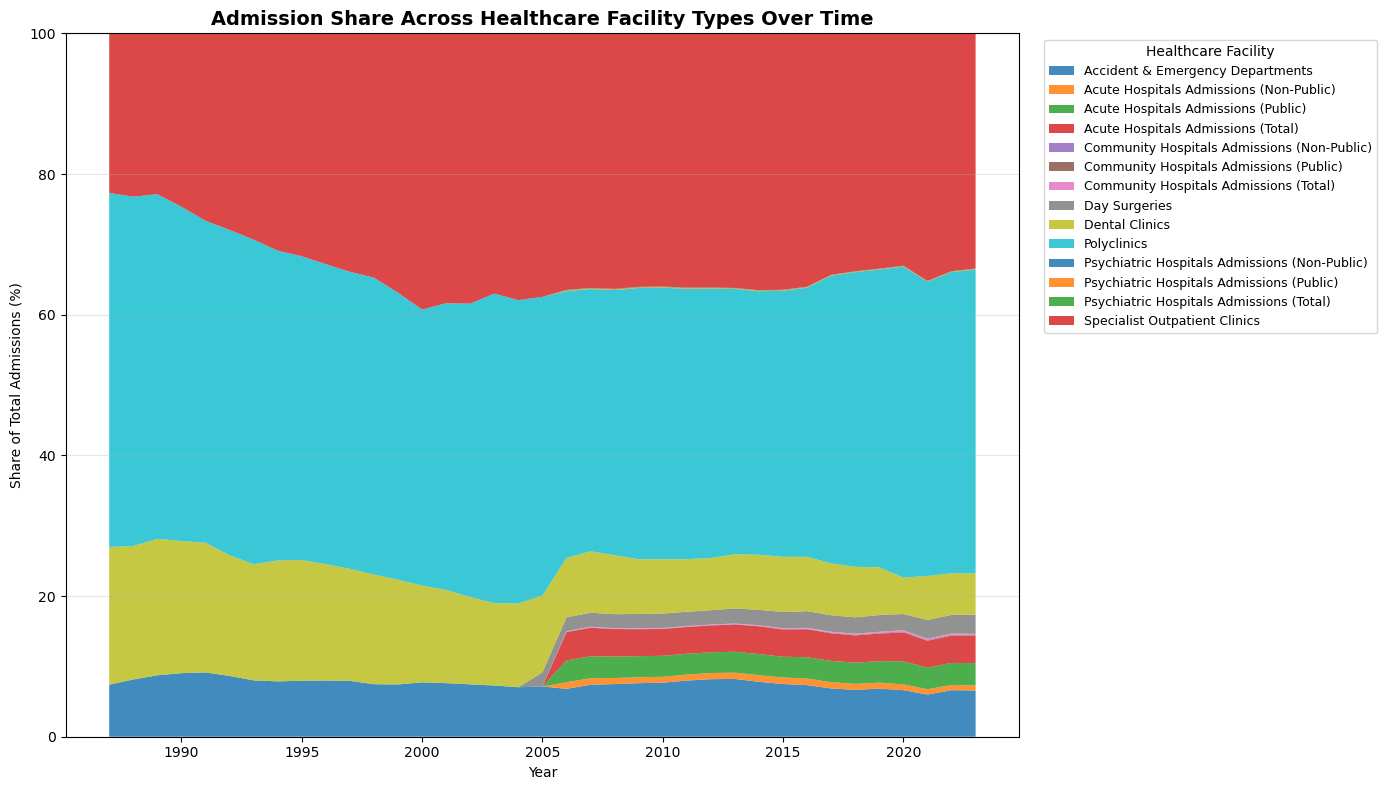

In [18]:
# 3. Admission share across facility types over time
# Reason: Able to see which facilities are becoming relatively more important
# Viz: 100% stacked chart

# Facilities to exclude: the Public/Non-Public breakdowns (keep only Total for these)
exclude_facilities = [
    'Community Hospitals Admissions (Non-Public)',
    'Community Hospitals Admissions (Public)',
    'Acute Hospitals Admissions (Public)',
    'Acute Hospitals Admissions (Non-Public)',
    'Psychiatric Hospitals Admissions (Non-Public)',
    'Psychiatric Hospitals Admissions (Public)',
]

filtered_df = healthcare_facilities_df[
    ~healthcare_facilities_df['Healthcare Facilities'].isin(exclude_facilities)
].copy()

# --- Pivot to wide format ---
pivot_df = yearly_admissions.pivot(index='Year', columns='Healthcare Facilities', values='Admission Counts')
pivot_df = pivot_df.fillna(0)

# --- Convert to percentage share per year ---
share_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# --- Plot 100% stacked area chart ---
plt.figure(figsize=(14, 8))
plt.stackplot(
    share_df.index,
    share_df.T.values,
    labels=share_df.columns,
    alpha=0.85
)

plt.title('Admission Share Across Healthcare Facility Types Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Share of Total Admissions (%)')
plt.ylim(0, 100)
plt.legend(title='Healthcare Facility', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Pending commentary for above graph

# First Visualization

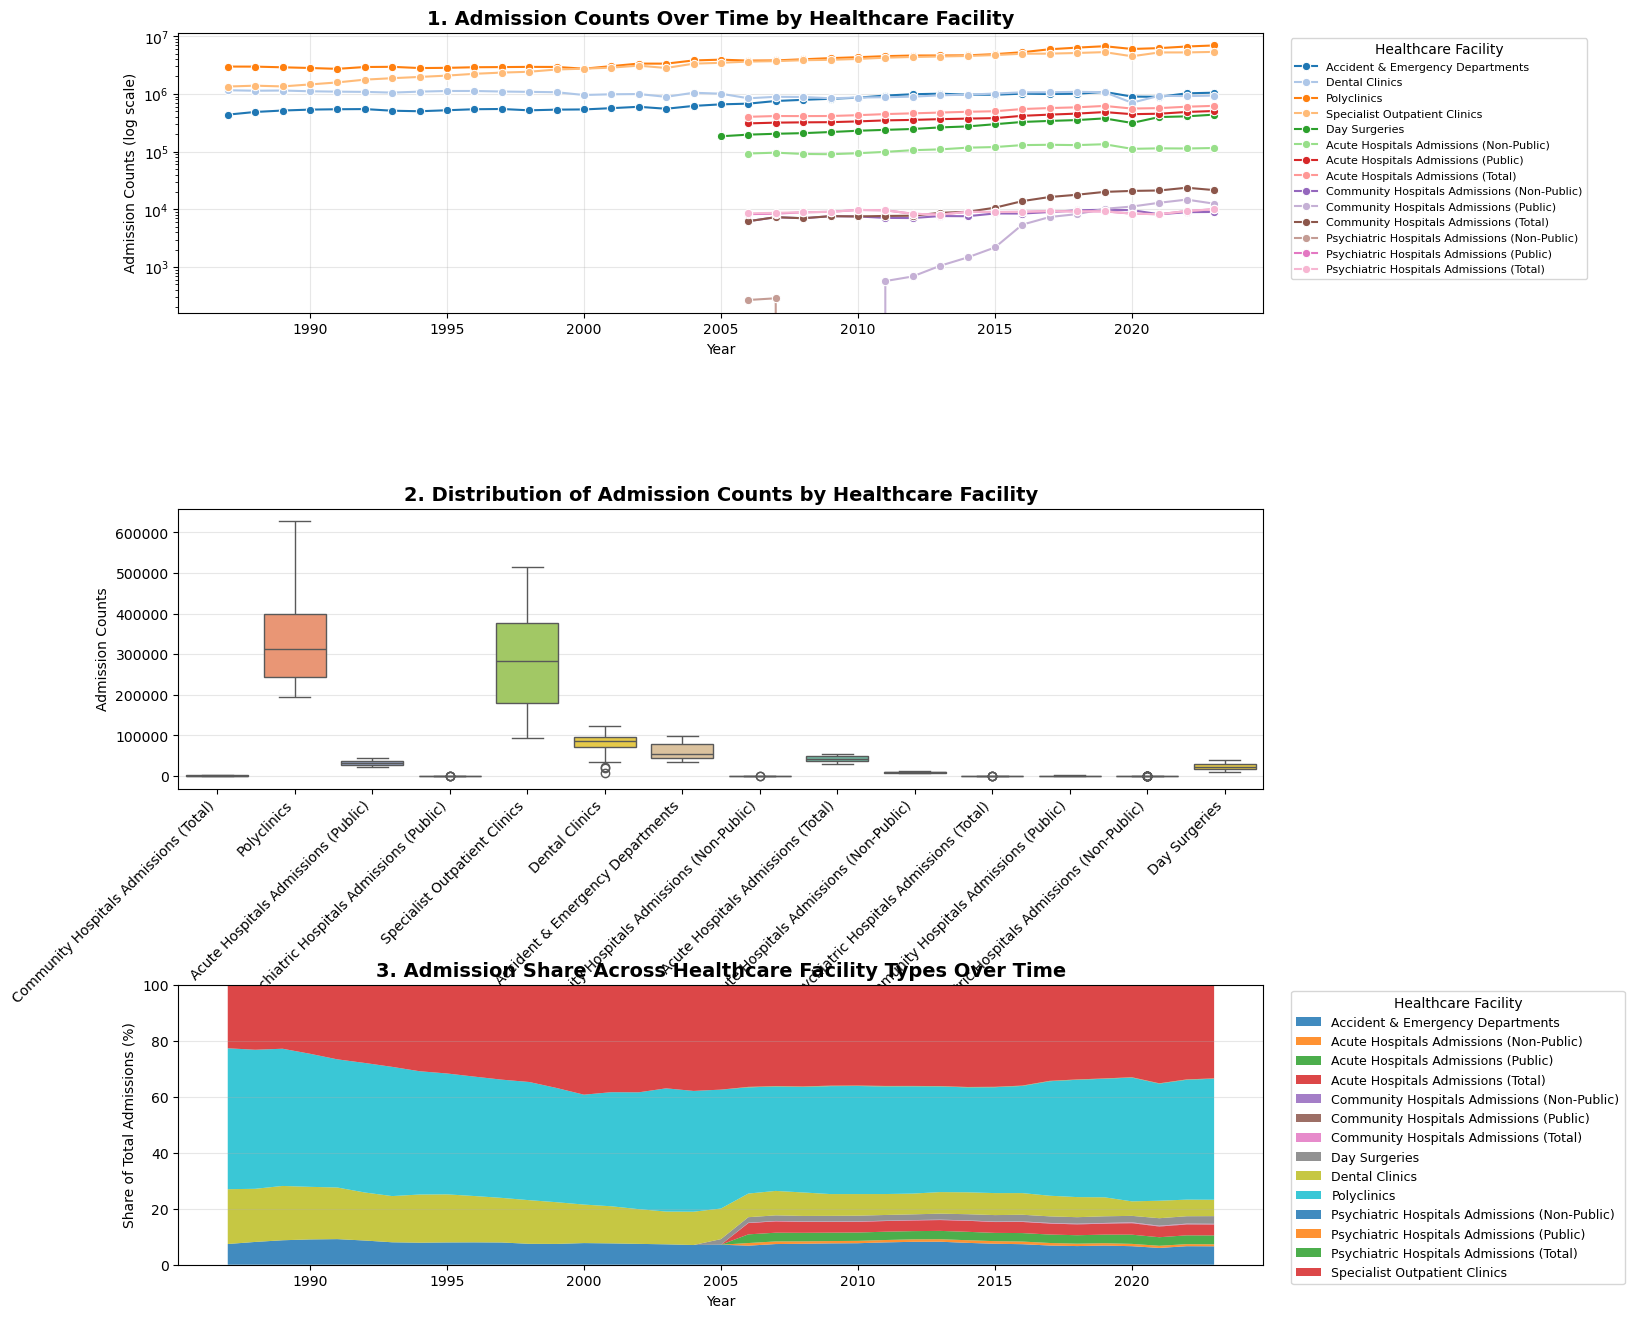

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# --- Panel 1: Line chart ---
sns.lineplot(
    data=yearly_admissions,
    x='Year',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette=sns.color_palette('tab20', n_colors=yearly_admissions['Healthcare Facilities'].nunique()),
    marker='o',
    ax=axes[0]
)
axes[0].set_title('1. Admission Counts Over Time by Healthcare Facility', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Admission Counts (log scale)')
axes[0].set_yscale('log')
axes[0].legend(title='Healthcare Facility', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3)

# --- Panel 2: Boxplot ---
sns.boxplot(
    data=healthcare_facilities_df,
    x='Healthcare Facilities',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette='Set2',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('2. Distribution of Admission Counts by Healthcare Facility', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Healthcare Facility')
axes[1].set_ylabel('Admission Counts')
axes[1].tick_params(axis='x', rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha('right')
axes[1].grid(alpha=0.3, axis='y')

# --- Panel 3: 100% stacked area chart ---
axes[2].stackplot(
    share_df.index,
    share_df.T.values,
    labels=share_df.columns,
    alpha=0.85
)
axes[2].set_title('3. Admission Share Across Healthcare Facility Types Over Time', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Share of Total Admissions (%)')
axes[2].set_ylim(0, 100)
axes[2].legend(title='Healthcare Facility', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[2].grid(alpha=0.3, axis='y')

plt.subplots_adjust(hspace=0.7)
plt.show()

#### Hospital Admission Rate by Gender and Age

In [ ]:
hospital_admissions_df = pd.read_csv("C:/Users/tk_ko/Desktop/SGH/2. Hospital Admission Rate by Gender and Age.csv")

In [20]:
# Display the first 10 rows
hospital_admissions_df.head(10)

,Age Group,Gender,Hospital Type,Year,Admission Rate (Per 1000 Resident)
0,65 Years Old & Above,Female,Acute Hospitals,2020,274.6
1,0 - 14 Years Old,Male,Psychiatric Hospitals,2011,0.1
2,15 - 64 Years Old,Male,Community Hospitals,2014,0.6
3,0 - 14 Years Old,Female,Acute Hospitals,2009,84.9
4,0 - 14 Years Old,Female,Community Hospitals,2013,0
5,15 - 64 Years Old,Male,Acute Hospitals,2011,65.4
6,15 - 64 Years Old,Male,Acute Hospitals,2012,66.7
7,65 Years Old & Above,Male,Community Hospitals,2017,23.4
8,0 - 14 Years Old,Male,Psychiatric Hospitals,2013,0.2
9,0 - 14 Years Old,Male,Acute Hospitals,2016,142.1


In [22]:
# Describe the info of each column
hospital_admissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age Group                           324 non-null    object
 1   Gender                              324 non-null    object
 2   Hospital Type                       324 non-null    object
 3   Year                                324 non-null    int64 
 4   Admission Rate (Per 1000 Resident)  324 non-null    object
dtypes: int64(1), object(4)
memory usage: 12.8+ KB


In [36]:
# Admission Rate (Per 1000 Resident) is a categorical variable. There could be odd one-off values besides numerical counts
# str converts each value to its string form before comparing, and allowed sorted to work
hospital_unique_vals = hospital_admissions_df['Admission Rate (Per 1000 Resident)'].unique()
print(sorted(hospital_unique_vals, key=str))

['-', '0', '0.1', '0.2', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1', '1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '100.1', '101.2', '102', '104.3', '109.4', '110.9', '111.6', '112', '118.5', '119.7', '12.2', '12.8', '120.2', '121.5', '121.8', '123.4', '124.3', '126.6', '127', '128.5', '13', '13.5', '13.6', '13.9', '131.8', '139.5', '14.1', '14.4', '14.9', '140.4', '142.1', '142.7', '145.4', '148.4', '15.6', '16', '16.4', '16.7', '16.8', '16.9', '17.5', '18', '2', '2.1', '2.2', '2.3', '2.4', '2.5', '2.6', '2.7', '2.8', '2.9', '20.3', '22.5', '23', '23.3', '23.4', '24.1', '24.8', '25', '25.5', '25.6', '26.2', '26.7', '27.9', '274.6', '286', '287.7', '292.9', '294.8', '295.3', '295.7', '299.8', '299.9', '3', '3.1', '3.2', '3.3', '3.5', '302.6', '303.7', '304', '307.7', '308', '313.8', '314.1', '318.9', '319.8', '323', '333.2', '337.9', '338.4', '339.6', '340.4', '343.7', '345.2', '347.6', '347.7', '348.4', '366.7', '368.2', '369.1', '371.8', '373.4', '376.5', '62.6', 

In [57]:
# Find rows where Admission Rate is '-', removing leading and trailing spaces and checking whether the cleaned value is exactly '-'
hospital_dash_mask = hospital_admissions_df['Admission Rate (Per 1000 Resident)'].astype(str).str.strip().eq('-')
hospital_dash_rows = hospital_admissions_df[hospital_dash_mask]

# Confirm that hospital_dash_rows only contain '-'
hospital_dash_rows['Admission Rate (Per 1000 Resident)'].value_counts(dropna=False)

Admission Rate (Per 1000 Resident)
-    9
Name: count, dtype: int64

In [59]:
# Keep only non-dash rows
hospital_admissions_df = hospital_admissions_df[~hospital_dash_mask]

# Confirm there are no more '-' rows
hospital_admissions_df['Admission Rate (Per 1000 Resident)'].astype(str).str.strip().eq('-').sum()

np.int64(0)

In [62]:
# Convert Admission Rate from object to numeric
hospital_admissions_df['Admission Rate (Per 1000 Resident)'] = pd.to_numeric(hospital_admissions_df['Admission Rate (Per 1000 Resident)'])

In [63]:
# Sanity check on Admission Counts column to check the distribution of values using describe()
hospital_admissions_df['Admission Rate (Per 1000 Resident)'].describe().T

count    315.000000
mean      61.988571
std      103.434386
min        0.000000
25%        0.600000
50%        3.000000
75%       84.600000
max      376.500000
Name: Admission Rate (Per 1000 Resident), dtype: float64

# Pending Commentary for above

In [64]:
# Check for nulls
hospital_admissions_df.isnull().sum()

Age Group                             0
Gender                                0
Hospital Type                         0
Year                                  0
Admission Rate (Per 1000 Resident)    0
dtype: int64

In [66]:
# Check for duplicate rows
hospital_duplicates = hospital_admissions_df.duplicated()
hospital_admissions_df[hospital_duplicates]

,Age Group,Gender,Hospital Type,Year,Admission Rate (Per 1000 Resident)


In [32]:
# Exploring the range of values in the remaining columns to check unexpected values
print(hospital_admissions_df['Age Group'].value_counts(), '\n')
print(hospital_admissions_df['Gender'].value_counts(), '\n')
print(hospital_admissions_df['Hospital Type'].value_counts(), '\n')
print(hospital_admissions_df['Year'].value_counts(), '\n')

Age Group
65 Years Old & Above    108
0 - 14 Years Old        108
15 - 64 Years Old       108
Name: count, dtype: int64 

Gender
Female    162
Male      162
Name: count, dtype: int64 

Hospital Type
Acute Hospitals          108
Psychiatric Hospitals    108
Community Hospitals      108
Name: count, dtype: int64 

Year
2020    18
2011    18
2010    18
2023    18
2022    18
2019    18
2006    18
2015    18
2018    18
2008    18
2007    18
2016    18
2017    18
2012    18
2013    18
2009    18
2014    18
2021    18
Name: count, dtype: int64 



# Pending commentary for above

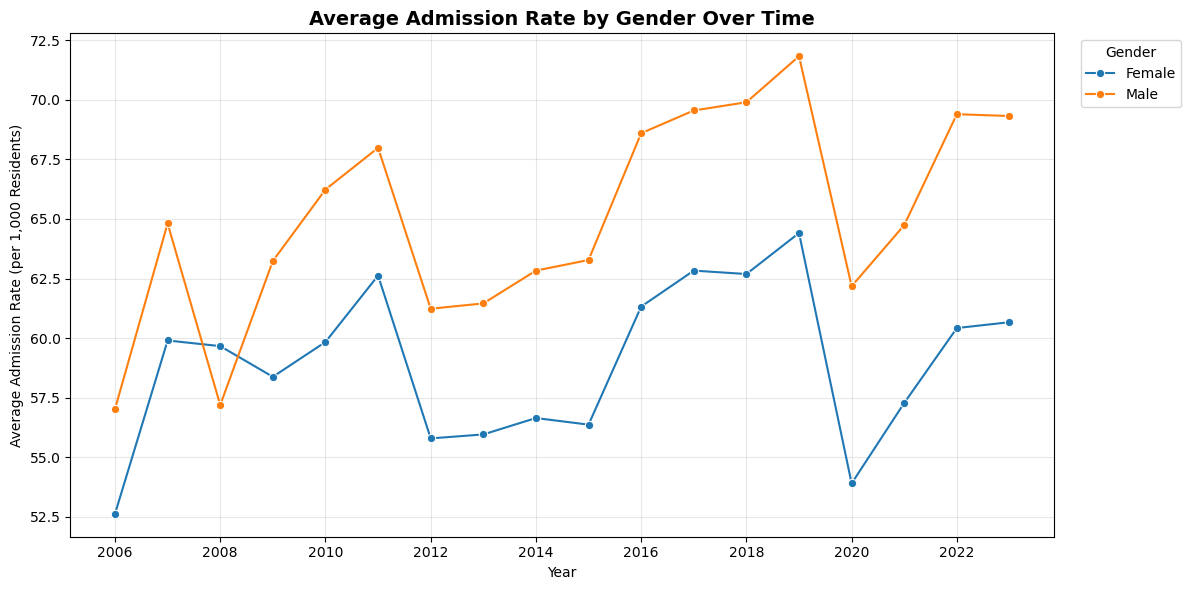

In [78]:
# Basic EDA
# 1. Admission rate by gender over time
# Reason: Trends in sex-specific healthcare demand that is easy to communicate. See if any significant shifts that communicate demand changes
# Viz: Line chart. x-axis = Year, y-axis = Admission rate, Legend = Gender

# --- Aggregate: average admission rate per year per gender ---
gender_rate_by_year = (
    hospital_admissions_df
    .groupby(['Year', 'Gender'], as_index=False)['Admission Rate (Per 1000 Resident)']
    .mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=gender_rate_by_year,
    x='Year',
    y='Admission Rate (Per 1000 Resident)',
    hue='Gender',
    marker='o'
)

plt.title('Average Admission Rate by Gender Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Admission Rate (per 1,000 Residents)')
plt.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Males consistently show higher average admission rates than Females across every year, with 2008 as the exception where it dipped to 57.19, falling below 59.66 for Females. 

The two genders also move roughly in parallel, suggesting that the gender gap in hospital admissions has remained stable over time. This consistent gap suggests higher healthcare usage among Males relative to Females.

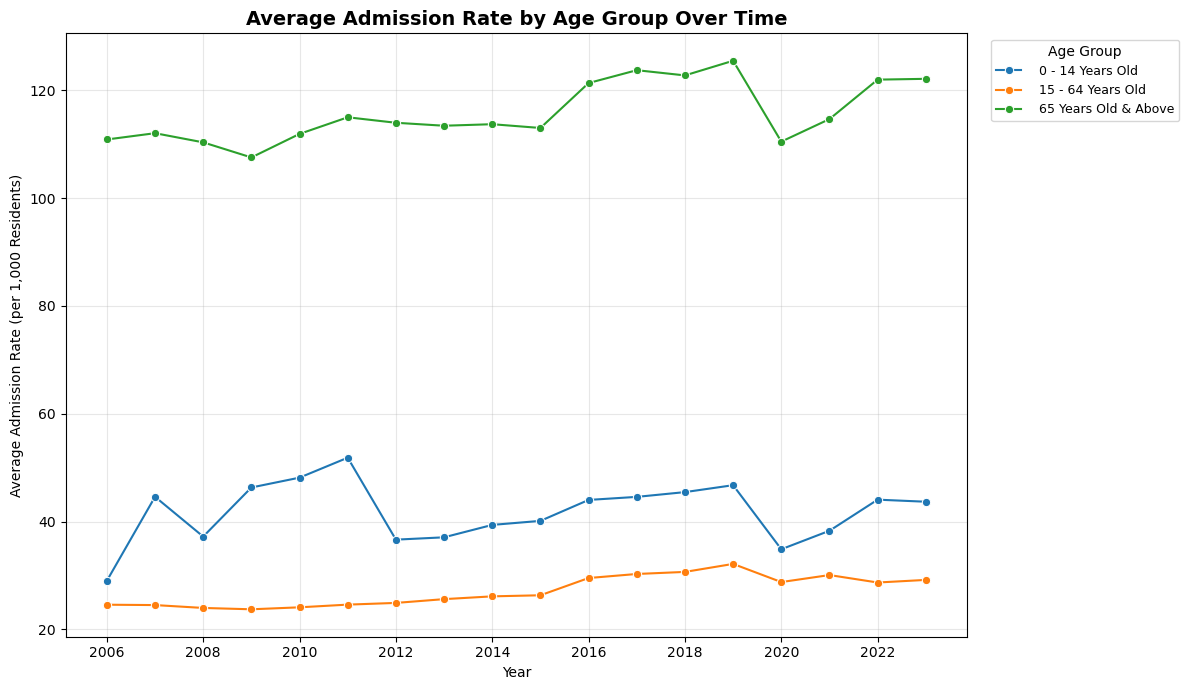

In [81]:
# 2. Admission rate by age over time
# Reason: Age is strongest driver of admission rates. Able to see which age segments generate the highest burden and whether rates change within groups over time
# Viz: Line chart. x-axis = Year, y-axis = Admission rate, Legend = Age group

# --- Aggregate: average admission rate per year per age group (equal-weighted, as agreed) ---
age_rate_by_year = (
    hospital_admissions_df
    .groupby(['Year', 'Age Group'], as_index=False)['Admission Rate (Per 1000 Resident)']
    .mean()
)

# --- Plot ---
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=age_rate_by_year,
    x='Year',
    y='Admission Rate (Per 1000 Resident)',
    hue='Age Group',
    marker='o'
)

plt.title('Average Admission Rate by Age Group Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Admission Rate (per 1,000 Residents)')
plt.legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

65 years old & above have consistently the highest average admission rates, with the gap between the other two age groups (0-14 years and 15-64 years) remaining stable across the years. As the population continues to age, there will be implications for long-term healthcare capacity planning.

Notably, all three age groups dipped sharply in 2020 and climbed again in 2022-2023. The dip could be a sign of COVID-19 where there might be lockdown-related reduced hospital visits or fear of exposure rather than a genuine decline in health needs.

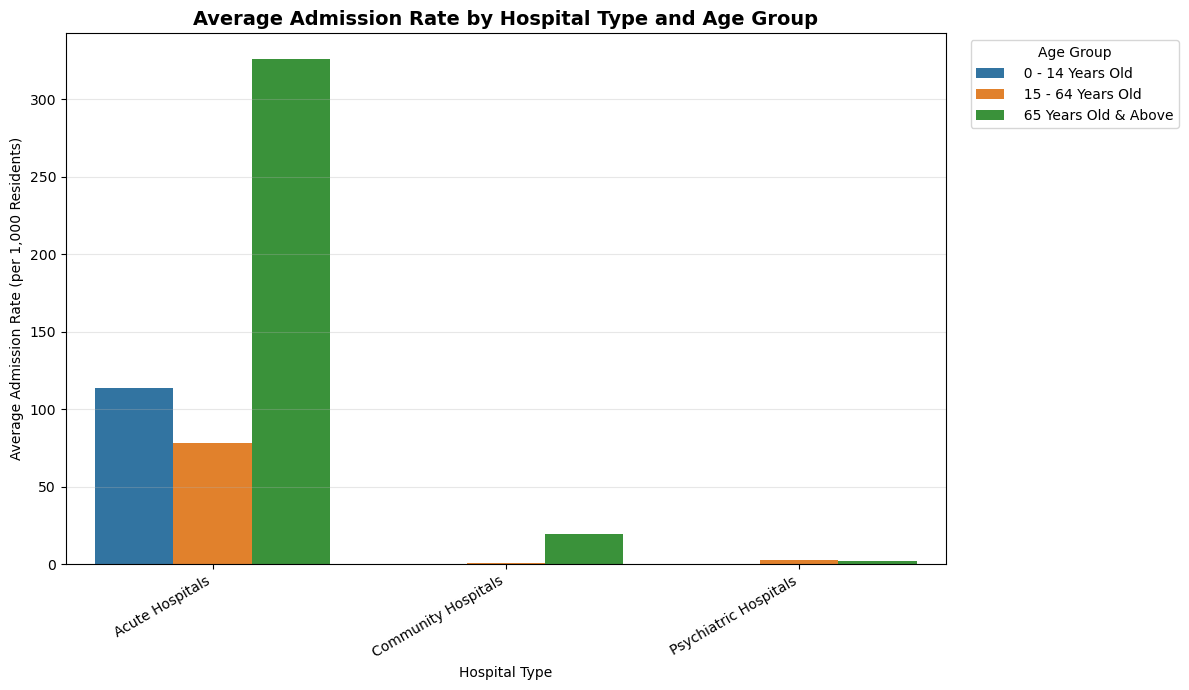

In [96]:
# 3. Admission rate by hospital type by age group
# Reason: Hospital utilization differs more strongly by age than by gender, espcailly when comparing acute, community and psychiatric settings
# Viz: Clustered bar chart. x-axis: Hospital Type, y-axis: Admission Rate, Hue: Age Group

# --- Aggregate: average admission rate per hospital type per age group (equal-weighted) ---
hospital_age_rate = (
    hospital_admissions_df
    .groupby(['Hospital Type', 'Age Group'], as_index=False)['Admission Rate (Per 1000 Resident)']
    .mean()
)

# --- Plot: clustered bar chart ---
plt.figure(figsize=(12, 7))
sns.barplot(
    data=hospital_age_rate,
    x='Hospital Type',
    y='Admission Rate (Per 1000 Resident)',
    hue='Age Group'
)

plt.title('Average Admission Rate by Hospital Type and Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Hospital Type')
plt.ylabel('Average Admission Rate (per 1,000 Residents)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Acute Hospitals have the highest average admission rates among hospital types, with 65 years old & above at the highest rate of 326.05 per 1000 residents, more than 4 times higher than the 15-64 years old rate of 77.99. Community Hospitals are also almost exclusive to the elderly, which is
consistent with their typical role of serving elderly patients recovering from acute conditions.

Interestingly, the elderly (2.01) are not the highest rate age group in Psychiatric Hospitals but 15-64 years old (2.50). This means that working-age adults use psychiatric care more than the elderly, and provides an alternative observation contrary to the age-driven trend seen in Acute and Community Hospitals.

# Second Visualization

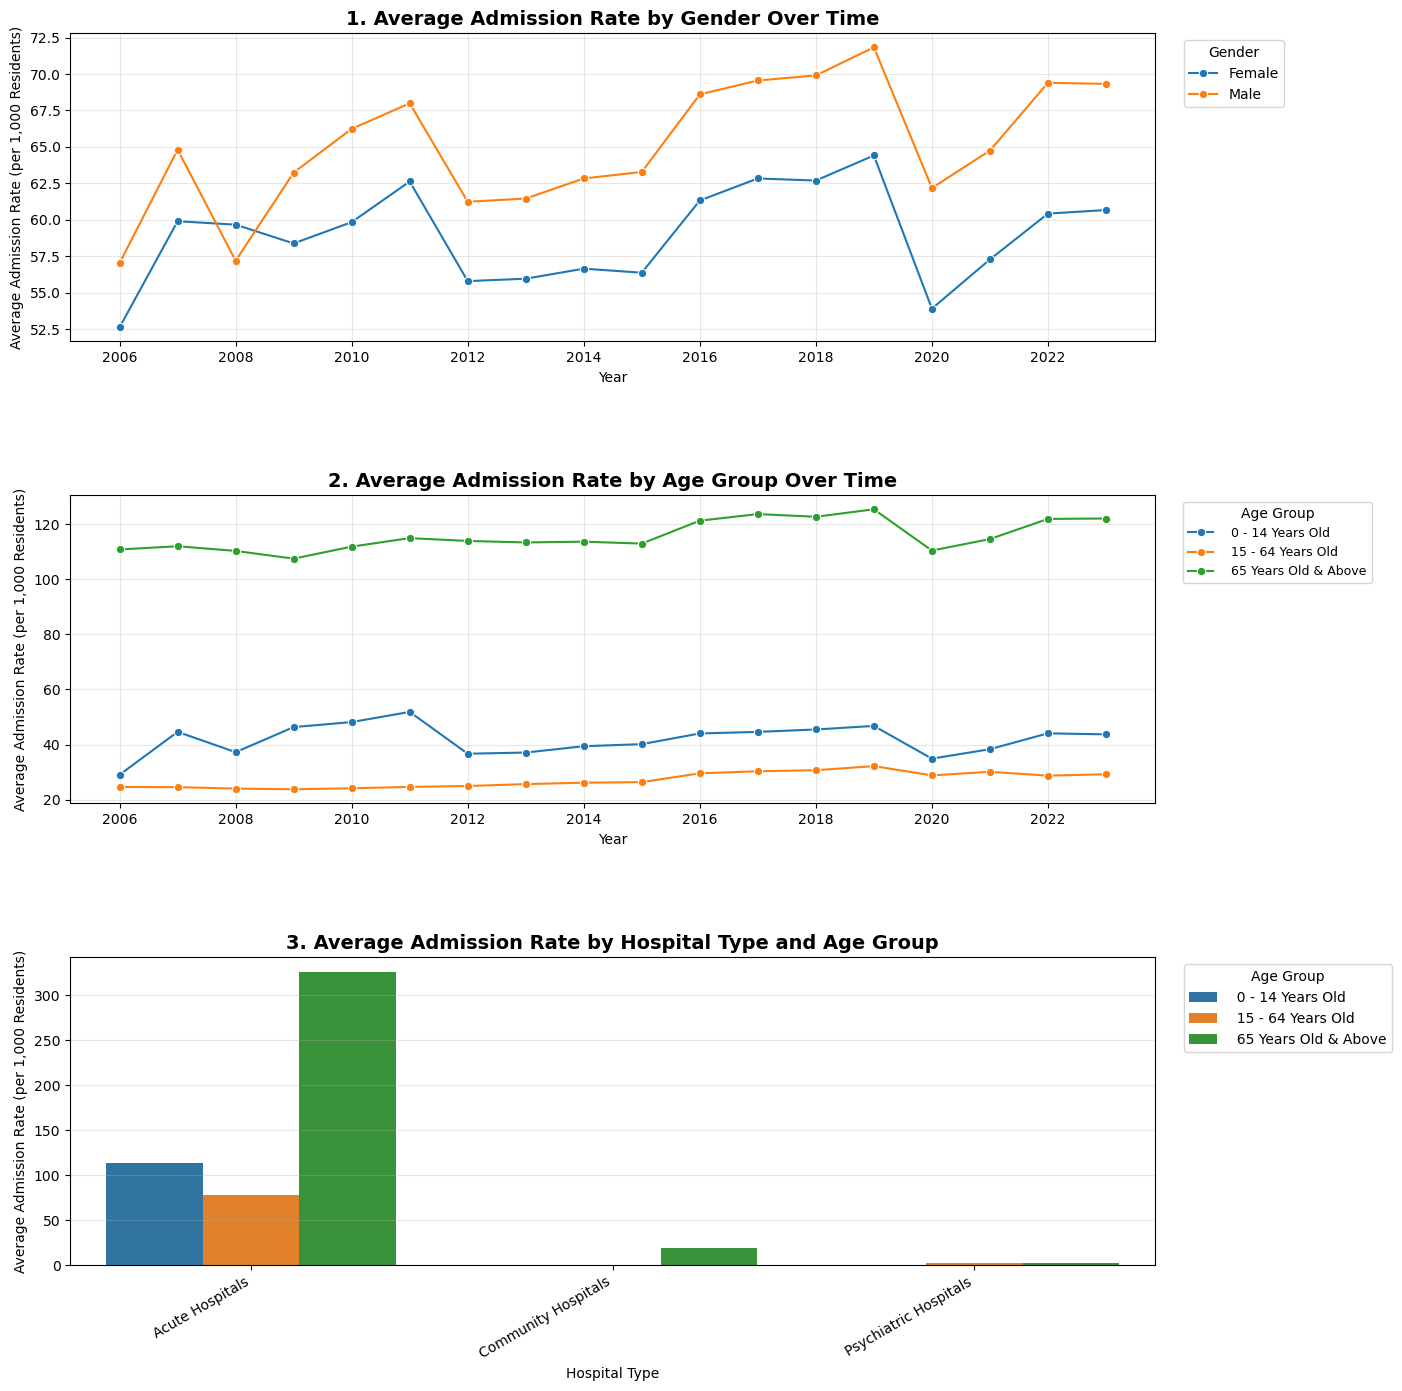

In [99]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# --- Panel 1: Admission Rate by Gender Over Time ---
gender_rate_by_year = (
    hospital_admissions_df
    .groupby(['Year', 'Gender'], as_index=False)['Admission Rate (Per 1000 Resident)']
    .mean()
)

sns.lineplot(
    data=gender_rate_by_year,
    x='Year',
    y='Admission Rate (Per 1000 Resident)',
    hue='Gender',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('1. Average Admission Rate by Gender Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Admission Rate (per 1,000 Residents)')
axes[0].legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].grid(alpha=0.3)

# --- Panel 2: Admission Rate by Age Group Over Time ---
age_rate_by_year = (
    hospital_admissions_df
    .groupby(['Year', 'Age Group'], as_index=False)['Admission Rate (Per 1000 Resident)']
    .mean()
)

sns.lineplot(
    data=age_rate_by_year,
    x='Year',
    y='Admission Rate (Per 1000 Resident)',
    hue='Age Group',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('2. Average Admission Rate by Age Group Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Admission Rate (per 1,000 Residents)')
axes[1].legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].grid(alpha=0.3)

# --- Panel 3: Admission Rate by Hospital Type and Age Group ---
hospital_age_rate = (
    hospital_admissions_df
    .groupby(['Hospital Type', 'Age Group'], as_index=False)['Admission Rate (Per 1000 Resident)']
    .mean()
)

sns.barplot(
    data=hospital_age_rate,
    x='Hospital Type',
    y='Admission Rate (Per 1000 Resident)',
    hue='Age Group',
    ax=axes[2]
)
axes[2].set_title('3. Average Admission Rate by Hospital Type and Age Group', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Hospital Type')
axes[2].set_ylabel('Average Admission Rate (per 1,000 Residents)')
axes[2].tick_params(axis='x', rotation=30)
for label in axes[2].get_xticklabels():
    label.set_ha('right')
axes[2].legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[2].grid(alpha=0.3, axis='y')

plt.subplots_adjust(hspace=0.5)
plt.show()

#### Prevalence of Health Indicators for SG adults

In [101]:
risk_factor_df = pd.read_excel("C:/Users/tk_ko/Desktop/SGH/3. Prevalence of Health Indicators for SG adults.xlsx", 
                               sheet_name = '3. Prevalence of Health Indicat')

In [102]:
# Display the first 10 rows
risk_factor_df.head(10)

,Risk Factor,Gender Category,Year,Proportion
0,Diabetes Mellitus,Female,2021,na
1,Obese,Total,2022,11.6
2,Daily Smoking,Male,2017,20.6
3,Binge Drinking,Male,2019,14.9
4,Sufficient Total Physical Activity,Male,2013,82.5
5,Hyperlipidaemia,Total,2017,35.5
6,Hyperlipidaemia,Male,2017,42.8
7,Sufficient Total Physical Activity,Total,2010,na
8,Daily Smoking,Male,2022,16
9,Obese,Male,2010,11.7


In [103]:
# Describe the info of each column
risk_factor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Risk Factor      216 non-null    object
 1   Gender Category  216 non-null    object
 2   Year             216 non-null    int64 
 3   Proportion       216 non-null    object
dtypes: int64(1), object(3)
memory usage: 6.9+ KB


In [106]:
# Proportion is a categorical variable. There could be odd one-off values besides numerical counts
risk_unique_vals = risk_factor_df['Proportion'].unique()
print(sorted(risk_unique_vals, key=str))

[10, 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 11.6, 11.7, 11.8, 11.9, 13.1, 13.3, 13.7, 13.8, 13.9, 14.6, 14.9, 15.7, 16, 17, 17.6, 17.8, 18.4, 19.2, 19.8, 2.2, 2.3, 2.7, 20.6, 20.7, 21.7, 22, 23, 23.1, 23.6, 23.9, 24, 24.2, 24.3, 24.6, 25.7, 26.2, 27, 27.5, 27.9, 28.5, 28.6, 28.8, 29.8, 3.2, 3.3, 3.4, 3.6, 3.8, 30.2, 30.8, 31.9, 33.4, 33.5, 35.1, 35.5, 35.8, 36.2, 37, 39.1, 4.1, 4.2, 4.3, 4.7, 41, 42.8, 44, 5.6, 5.7, 6.4, 6.5, 7, 7.1, 7.3, 7.4, 7.8, 73.2, 74.1, 74.9, 76, 76.6, 76.7, 76.9, 78.1, 78.5, 79.5, 8, 8.4, 8.5, 8.6, 8.8, 80, 80.4, 80.6, 80.7, 82.5, 83.5, 83.6, 84, 84.6, 85.2, 85.4, 85.6, 85.7, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7, 'na']


In [113]:
# Find rows where Proportion is 'na', removing leading and trailing spaces and checking whether the cleaned value is exactly 'na'
risk_na_mask = risk_factor_df['Proportion'].astype(str).str.strip().eq('na')
risk_na_rows = risk_factor_df[risk_na_mask]

# Confirm that risk_na_rows only contain 'na'
risk_na_rows['Proportion'].value_counts(dropna=False)

Proportion
na    75
Name: count, dtype: int64

In [114]:
# Keep only non-na rows
risk_factor_df = risk_factor_df[~risk_na_mask]

# Confirm there are no more 'na' rows
risk_factor_df['Proportion'].astype(str).str.strip().eq('na').sum()

np.int64(0)

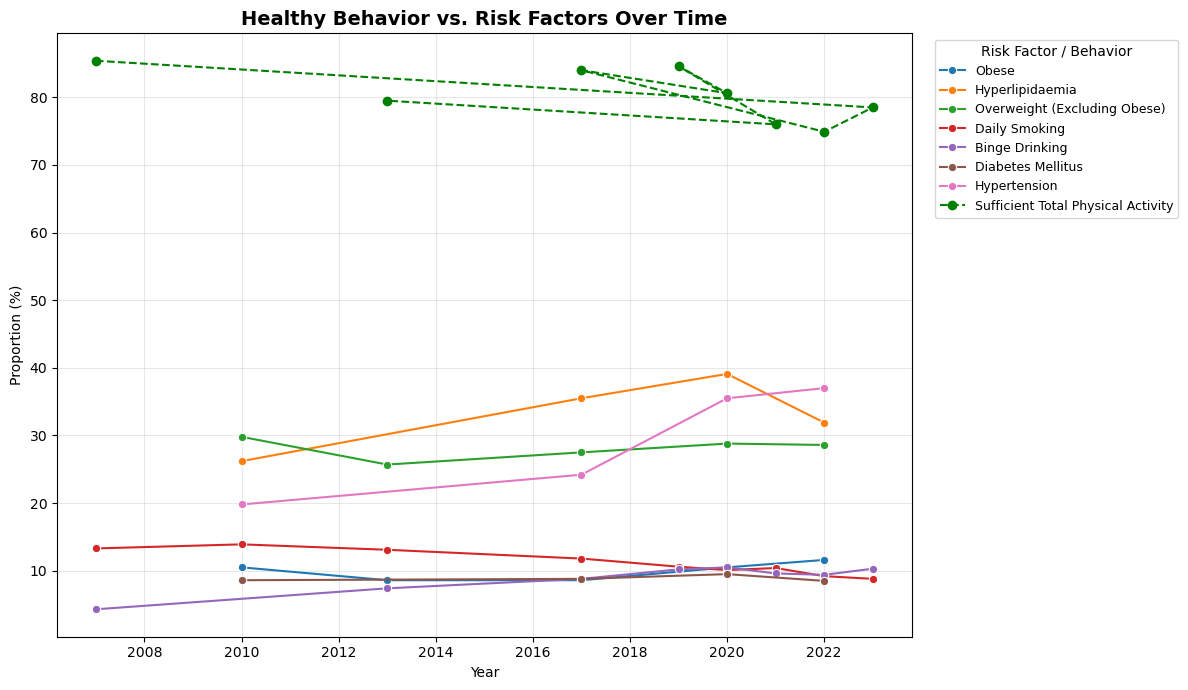

In [119]:
# --- Filter to Total gender category only ---
total_df = risk_factor_df[risk_factor_df['Gender Category'] == 'Total'].copy()

# --- Plot ---
plt.figure(figsize=(12, 7))

risk_factors = [rf for rf in total_df['Risk Factor'].unique() if rf != 'Sufficient Total Physical Activity']

# Plot risk factors
sns.lineplot(
    data=total_df[total_df['Risk Factor'].isin(risk_factors)],
    x='Year',
    y='Proportion',
    hue='Risk Factor',
    marker='o',
)

# Plot healthy behavior separately, with a dotted green line
healthy_df = total_df[total_df['Risk Factor'] == 'Sufficient Total Physical Activity']
plt.plot(
    healthy_df['Year'],
    healthy_df['Proportion'],
    label='Sufficient Total Physical Activity',
    color='green',
    linestyle='--',
    marker='o'
)

plt.title('Healthy Behavior vs. Risk Factors Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Proportion (%)')
plt.legend(title='Risk Factor / Behavior', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Sufficient Total Physical Activity has had a steady decline, with several risk factors rising over the years. Physical Activity fell from 85.4% in 2007 to 78.5% in 2023. This shows that physical activity levels are not sufficient enough to offset the rising proportion of risk factors.

Among risk factors, hypertension shows the sharpest increase in prportion from 19.8% in 2010 to 37% in 2022. This increase outpaces any other risk factor. Hypertension and hyperlipidaemia are closely related co-morbodities and this is reflected in the increasing proportions over the years and ranking as the Top 2 risk factors in 2022.

Daily Smoking sees a consistent, sustained decline from 13.3% in 2007 to 8.8% in 2023. This likely reflects the sustained effort in anti-smoking campaigns and policies over the period.

Notably, Binge Drinking has more than doubled from 4.3% in 2007 to 10.3% in 2023. Alongside hypertension and hyperlipidaemia, Binge Drinking is a rising concern.

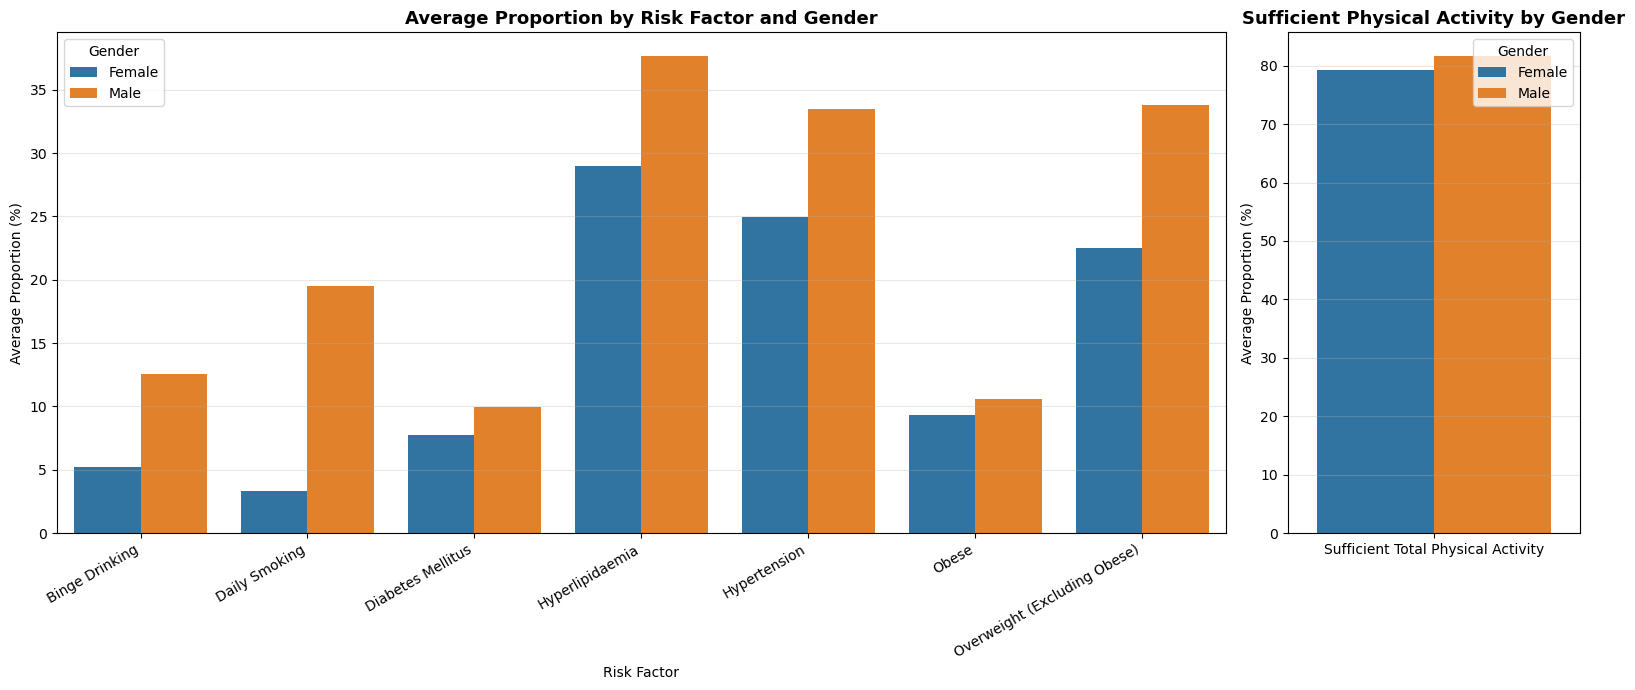

In [126]:
# 2. Male vs Female by risk factor 
# Reason: Uncover gender differences between risk factors
# Viz: Grouped bar chart. x-axis = Risk Factor, y-axis = Proportion, hue = Gender

# --- Filter to Male/Female only (exclude Total) ---
gender_df = risk_factor_df[risk_factor_df['Gender Category'].isin(['Male', 'Female'])].copy()

# --- Aggregate: average proportion per risk factor per gender (equal-weighted across years) ---
gender_risk = (
    gender_df
    .groupby(['Risk Factor', 'Gender Category'], as_index=False)['Proportion']
    .mean()
)

# --- Split: risk factors vs. healthy behavior ---
risk_only = gender_risk[gender_risk['Risk Factor'] != 'Sufficient Total Physical Activity']
activity_only = gender_risk[gender_risk['Risk Factor'] == 'Sufficient Total Physical Activity']

# --- Plot: two panels side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [4, 1]})

# Panel 1: Risk factors
sns.barplot(
    data=risk_only,
    x='Risk Factor',
    y='Proportion',
    hue='Gender Category',
    ax=axes[0]
)
axes[0].set_title('Average Proportion by Risk Factor and Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Factor')
axes[0].set_ylabel('Average Proportion (%)')
axes[0].tick_params(axis='x', rotation=30)
for label in axes[0].get_xticklabels():
    label.set_ha('right')
axes[0].legend(title='Gender')
axes[0].grid(alpha=0.3, axis='y')

# Panel 2: Sufficient Total Physical Activity
sns.barplot(
    data=activity_only,
    x='Risk Factor',
    y='Proportion',
    hue='Gender Category',
    ax=axes[1]
)
axes[1].set_title('Sufficient Physical Activity by Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Proportion (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Gender')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Males have consistently higher rates across every risk factor. 

Among risk factors, behavioral ones show the largest gender gaps while biological ones are much closer. Daily Smoking has the largest gap, with Males (19.51%) being 6 times higher than Females (3.3%). Obesity and Diabetes Mellitus are more balanced between genders, with Males only having slightly higher proportions. This reflects how Males also have different lifestyle behaviors that contribute significantly to these risk factors.

Overweight (Excluding Obese) shows Males at 33.8%, which is around 1.5 times higher than Females at 22.54%. This is a meaningful distinction when compared to obesity because Males are much more represented in the overweight category.

Interestingly, while Males have higher Sufficient Physical Activity than Females, it is insufficient to offset the higher risk factor burden in Males. This strongly suggests that other lifestyle drivers are more influential.

# Third Visualization

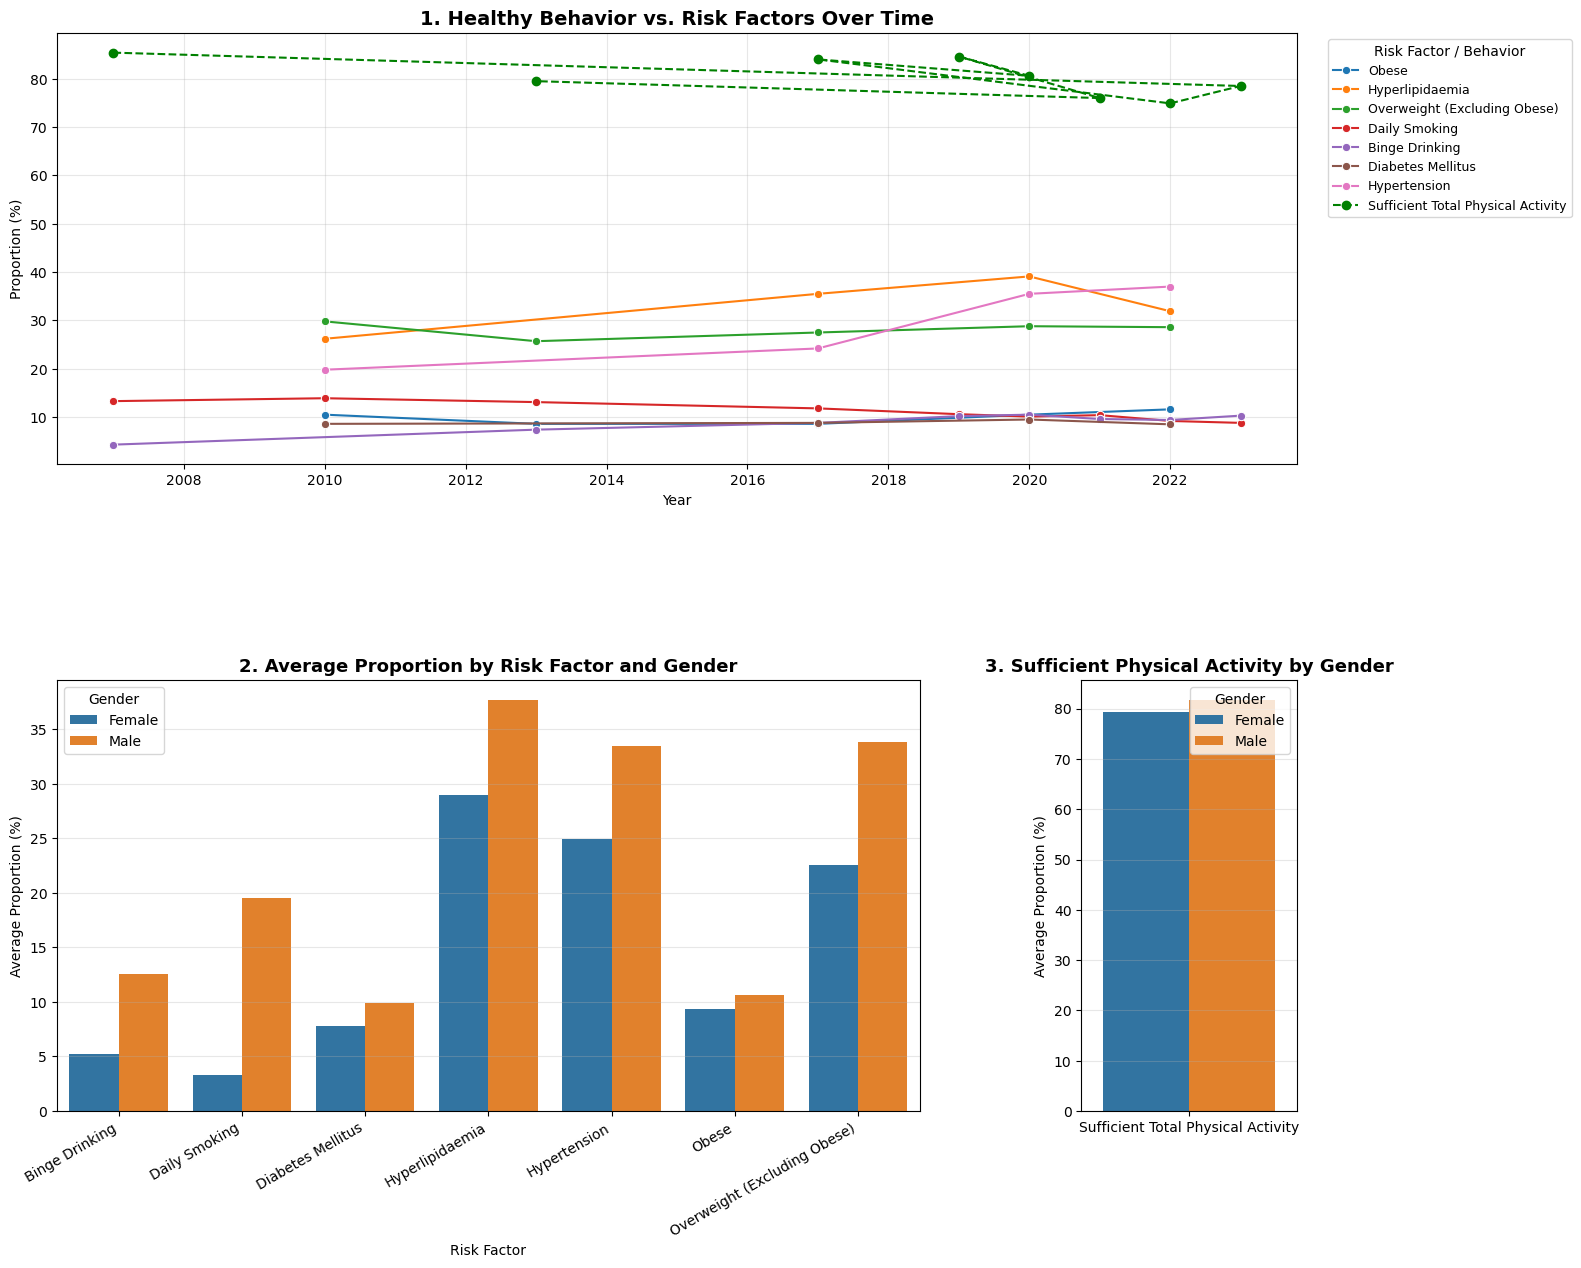

In [131]:
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[4, 1], hspace=0.5, wspace=0.3)

# --- Panel 1 (top, spans full width): Healthy Behavior vs Risk Factors Over Time ---
ax0 = fig.add_subplot(gs[0, :])

sns.lineplot(
    data=total_df[total_df['Risk Factor'].isin(risk_factors)],
    x='Year',
    y='Proportion',
    hue='Risk Factor',
    marker='o',
    ax=ax0
)

healthy_df = total_df[total_df['Risk Factor'] == 'Sufficient Total Physical Activity']
ax0.plot(
    healthy_df['Year'],
    healthy_df['Proportion'],
    label='Sufficient Total Physical Activity',
    color='green',
    linestyle='--',
    marker='o'
)

ax0.set_title('1. Healthy Behavior vs. Risk Factors Over Time', fontsize=14, fontweight='bold')
ax0.set_xlabel('Year')
ax0.set_ylabel('Proportion (%)')
ax0.legend(title='Risk Factor / Behavior', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax0.xaxis.set_major_locator(MaxNLocator(integer=True))
ax0.grid(alpha=0.3)

# --- Panel 2 (bottom-left): Risk factors by Gender ---
ax1 = fig.add_subplot(gs[1, 0])

sns.barplot(
    data=risk_only,
    x='Risk Factor',
    y='Proportion',
    hue='Gender Category',
    ax=ax1
)
ax1.set_title('2. Average Proportion by Risk Factor and Gender', fontsize=13, fontweight='bold')
ax1.set_xlabel('Risk Factor')
ax1.set_ylabel('Average Proportion (%)')
ax1.tick_params(axis='x', rotation=30)
for label in ax1.get_xticklabels():
    label.set_ha('right')
ax1.legend(title='Gender')
ax1.grid(alpha=0.3, axis='y')

# --- Panel 3 (bottom-right): Physical Activity by Gender ---
ax2 = fig.add_subplot(gs[1, 1])

sns.barplot(
    data=activity_only,
    x='Risk Factor',
    y='Proportion',
    hue='Gender Category',
    ax=ax2
)
ax2.set_title('3. Sufficient Physical Activity by Gender', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Average Proportion (%)')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Gender')
ax2.grid(alpha=0.3, axis='y')

plt.show()